In [7]:
import allel
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns

In [8]:
## the 70 assemblies from arabiodpsis
## only big svs (>10kb)
#1) 72accs.col_pek.corr.syri.flt_10k.refine.g3.mrg.vcf.gz (~0.7 MB) 
## from 20 bp to _10k variants ,, refine??
#2) 72accs.col_pek.corr.syri.flt_20_10k.refine.g2.mrg.vcf.gz (~17 MB)
## snps and smallest variants 
#3) 72accs.col_pek.ingap.flt.fin_mrg.refine.maxmiss02.biale.mindp6.maxdp226.snp.recode.vcf.gz (~1.05 GB)

In [ ]:
## generate these quick checks 

bcftools query -f '%CHROM\t%POS\t%ID\t%INFO/SVTYPE\t%INFO/SVLEN\n' \
  72accs.col_pek.ingap.flt.fin_mrg.refine.maxmiss02.biale.mindp6.maxdp226.snp.recode.vcf.gz 2>/dev/null \
> smv.tsv

In [9]:
vcf_sv = '/home/tbellagio/scratch/pang/pang_69/vcf/upload_vcf/72accs.col_pek.ingap.flt.fin_mrg.refine.maxmiss02.biale.mindp6.maxdp226.snp.recode.vcf.gz'
vcf_sv = allel.read_vcf(vcf_sv)


KeyboardInterrupt



In [ ]:
vcf_sv['calldata/GT'].shape

In [ ]:
lv = pd.read_csv('/home/tbellagio/scratch/pang/pang_69/vcf/upload_vcf/lv.tsv', sep = '\t', header=None)
mv = pd.read_csv('/home/tbellagio/scratch/pang/pang_69/vcf/upload_vcf/mv.tsv', sep = '\t', header=None)

In [ ]:
vcf_lv = '/home/tbellagio/scratch/pang/pang_69/vcf/upload_vcf/f.gz'
vcf_lv = allel.read_vcf(vcf_sv)

In [14]:
mv[4].describe()

count    52512.000000
mean       534.422875
std       1265.300774
min      -8334.000000
25%         27.000000
50%         48.000000
75%        428.000000
max       9991.000000
Name: 4, dtype: float64

In [15]:
lv[4].describe()

count    8.140000e+02
mean     2.188615e+05
std      4.606034e+05
min     -1.417700e+04
25%      1.047250e+04
50%      2.317650e+04
75%      1.814925e+05
max      3.466636e+06
Name: 4, dtype: float64

<Axes: xlabel='4', ylabel='Count'>

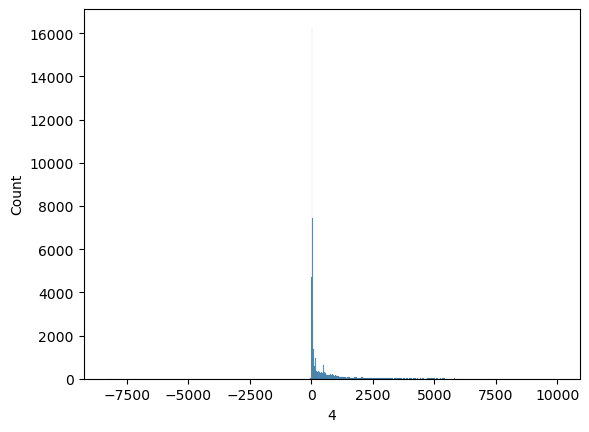

In [13]:
sns.histplot(mv[4])

In [5]:
base_path = '/home/tbellagio/scratch/pang/pang_experiment/pangenomes/set_02_rep1/output/'

In [9]:
vcf_top    = base_path + "set_02_rep1.deconstruct.top.vcf.gz"
vcf_all    = base_path + "set_02_rep1.deconstruct.all_snarls.vcf.gz"
vcf_nested = base_path + "set_02_rep1.deconstruct.nested.L1.0.vcf.gz"

In [10]:
vcf_top = allel.read_vcf(vcf_top)
calldata_top = vcf_top['calldata/GT']

#vcf_all = allel.read_vcf(vcf_all)
#calldata_all = vcf_all['calldata/GT']

#vcf_nested = allel.read_vcf(vcf_nested)
#calldata_nested = vcf_nested['calldata/GT']

In [11]:
print(calldata_top.shape)
print(calldata_all.shape)
print(calldata_nested.shape)

(786718, 1, 2)


NameError: name 'calldata_all' is not defined

In [ ]:
1208719 - 1129214

In [ ]:
## only 7 % are nested 
(79505 / 1129214 ) * 100

In [12]:
ref = vcf_top['variants/REF'].astype(str)
alt = vcf_top['variants/ALT']  # shape (n_variants, n_alts_max)

MemoryError: Unable to allocate 1.78 TiB for an array with shape (786718,) and data type <U620718

In [25]:
vcf_top

{'samples': array(['Mh-0', 'Ms-0'], dtype=object),
 'calldata/GT': array([[[ 1, -1],
         [ 2, -1]],
 
        [[ 1, -1],
         [ 0, -1]],
 
        [[ 1, -1],
         [ 1, -1]],
 
        ...,
 
        [[ 1, -1],
         [-1, -1]],
 
        [[ 1, -1],
         [-1, -1]],
 
        [[ 1, -1],
         [-1, -1]]], dtype=int8),
 'variants/ALT': array([['CTAAACCCTACCCTAACCCTAAACCCAAACCCTAAACCCTAAACTAACCTAAACCCTAAACCCTAAACCCTAAACCAAACCCTAAACCCTCAACCCTAAACCCTAAACCCTAAACCCTAAACCCTAACCCAAACCTAACCCTAAACCCTAACCCTAAACCCTAAACCCTAAACCCTAAACCCTAAACCTAAACCTAAACCCTAAACCCTAAACCCTAACCCTAAACCCTAAACCCTAACCCTAACCCTAAACCTAAACCCTAAACCCTAAACCCTAAACCCTAACCGACCCTAAACCCTAAACCCTAAACCCTAAACCCTAACCCTAAACCCTAAACCTAAACCCTAACCCTAAACCTAACCCTAACCCTAAACCCTAAACCCTAACCCTAAACCCTAAACCTAATCCCTAACCTACCCTAAACCTAAACCCTATACCCTAAACCTAAACCCTAAACCCTCAACCCTAAACCCTAAACCCTAAACCCTAAACCCTCTAACCCTAAACCCCTAACCCTAACCCCTAAACCCTCAACCTAAACCCTAAACCTAAACCCTAAACCCTACACCCTAAACCCTAAACCCTAAACCCTAAACCCTAAACCCTAAACCCTAAACCCTAAACCCTAAACCCTA

In [23]:

n_records = ref.shape[0]

# Count number of ALT alleles per site (ignore empty padding like '' or None)
# ALT can be dtype object; normalize empties.
alt_clean = np.where((alt == None) | (alt == ''), '', alt).astype(str)
n_alt = (alt_clean != '').sum(axis=1)

multiallelic_sites = int((n_alt > 1).sum())

# For classification, use the first ALT allele (bcftools counts per record/site)
alt1 = alt_clean[:, 0]

MemoryError: Unable to allocate 4.82 TiB for an array with shape (1129214,) and data type <U1172521

In [ ]:
bcftools view 